In [45]:
!curl -L -o ./data/mnist.zip\
  https://www.kaggle.com/api/v1/datasets/download/hojjatk/mnist-dataset
!unzip ./data/mnist.zip -d ./data/mnist

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 22.0M  100 22.0M    0     0  7545k      0  0:00:02  0:00:02 --:--:--  9.8M0:01 9260k
Archive:  ./data/mnist.zip
  inflating: ./data/mnist/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte  
  inflating: ./data/mnist/t10k-images.idx3-ubyte  
  inflating: ./data/mnist/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte  
  inflating: ./data/mnist/t10k-labels.idx1-ubyte  
  inflating: ./data/mnist/train-images-idx3-ubyte/train-images-idx3-ubyte  
  inflating: ./data/mnist/train-images.idx3-ubyte  
  inflating: ./data/mnist/train-labels-idx1-ubyte/train-labels-idx1-ubyte  
  inflating: ./data/mnist/train-labels.idx1-ubyte  


In [47]:
#
# This is a sample Notebook to demonstrate how to read "MNIST Dataset"
#
import numpy as np # linear algebra
import struct
from array import array
from os.path  import join

#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test) 

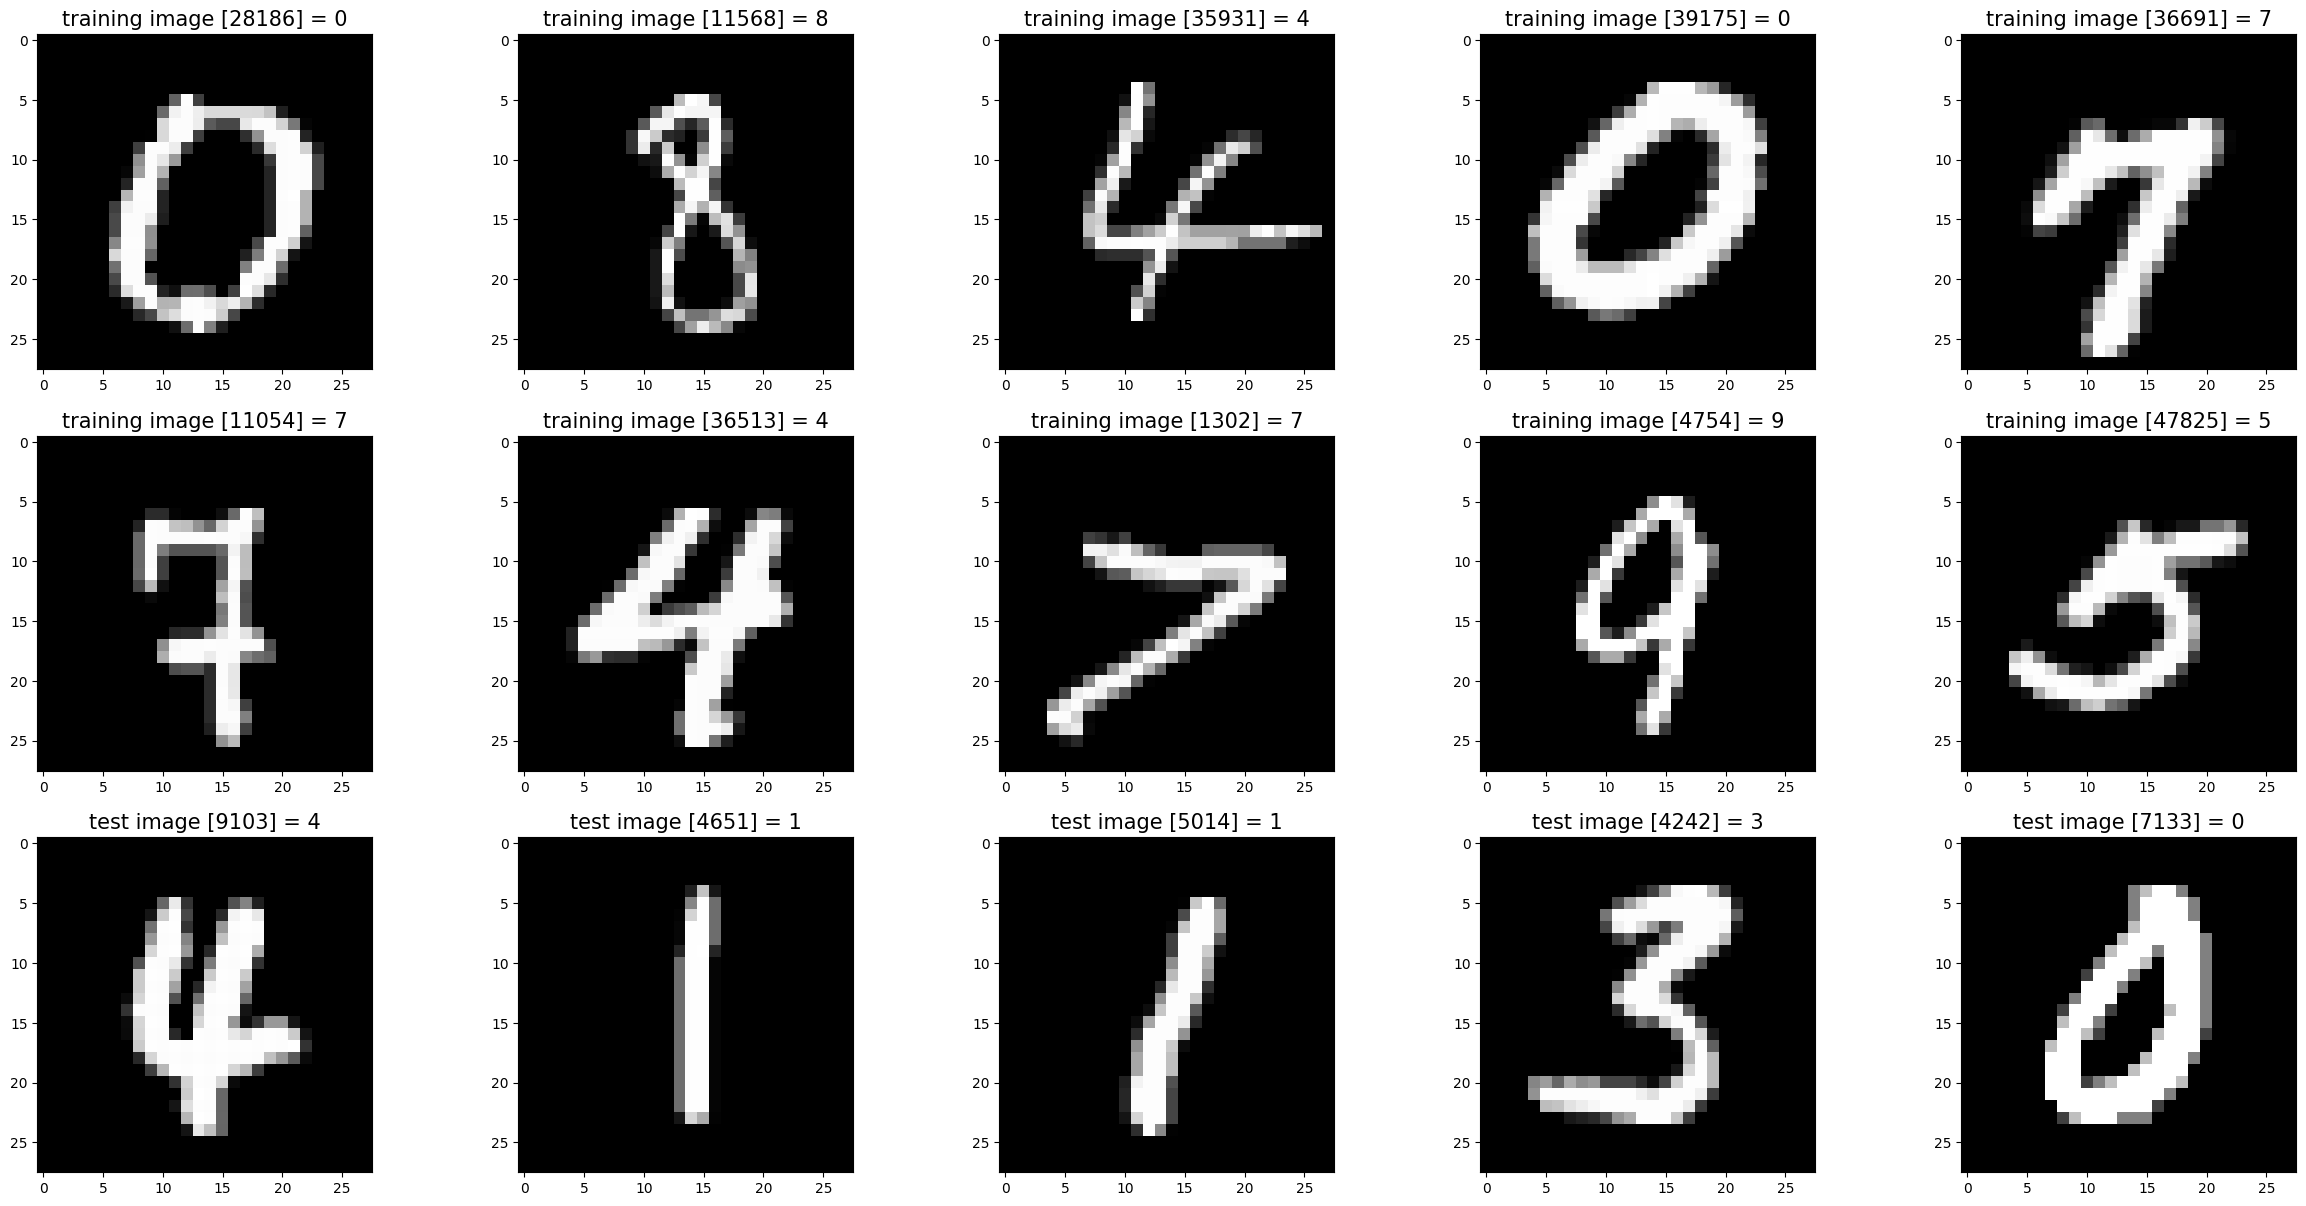

In [48]:
#
# Verify Reading Dataset via MnistDataloader class
#
%matplotlib inline
import random
import matplotlib.pyplot as plt

#
# Set file paths based on added MNIST Datasets
#
input_path = 'data/mnist'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1
    plt.show()
    
#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images 
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

In [50]:
class LinearLayer():
    def __init__(self, input_size, output_size):
        self.input_size = input_size
        self.output_size = output_size
        # He Initialization
        self.weights = np.random.randn(input_size, output_size) * np.sqrt(2. / input_size)
        self.biases = np.zeros((1, output_size))

    def forward(self, input_data):
        self.input_data = input_data
        return np.dot(input_data, self.weights) + self.biases

    def backward(self, output_gradient, learning_rate):
        weights_gradient = np.dot(self.input_data.T, output_gradient)
        input_gradient = np.dot(output_gradient, self.weights.T)

        self.weights -= learning_rate * weights_gradient
        self.biases -= learning_rate * np.sum(output_gradient, axis=0, keepdims=True)

        return input_gradient
    
class ReLULayer():
    def forward(self, input_data):
        self.input_data = input_data
        return np.maximum(0, input_data)

    def backward(self, output_gradient, learning_rate):
        input_gradient = output_gradient.copy()
        input_gradient[self.input_data <= 0] = 0
        return input_gradient
    
class SoftmaxLayer():
    def forward(self, input_data):
        exps = np.exp(input_data)
        self.output_data = exps / np.sum(exps, axis=1, keepdims=True)
        return self.output_data

    def backward(self, output_gradient, learning_rate):
        return output_gradient  # Gradient is passed through for cross-entropy loss
    
class CrossEntropyLoss():
    def forward(self, predictions, targets):
        self.predictions = predictions
        self.targets = targets
        m = targets.shape[0]
        log_likelihood = -np.log(predictions[range(m), targets])
        loss = np.sum(log_likelihood) / m
        return loss

    def backward(self):
        # self.targets = [0, 1, 2, ..., 9] for each sample
        # self.predictions = softmax outputs, shape (m, 10)
        # Y^ - Y
        # self.predictions[0] = [0.1, 0.2, 0.7] for sample [0, 0, 1]
        # [0, 0, 1] -> [2]
        m = self.targets.shape[0]
        grad = self.predictions.copy()
        one_hot_targets = np.zeros_like(self.predictions)
        one_hot_targets[np.arange(m), self.targets] = 1
        grad -= one_hot_targets
        grad /= m
        return grad

In [51]:
class NeuralNetwork():
    def __init__(self):
        self.W1 = LinearLayer(784, 10)
        self.activation1 = ReLULayer()
        self.W2 = LinearLayer(10, 10)
        self.softmax = SoftmaxLayer()
        self.activation2 = ReLULayer()
        self.loss_function = CrossEntropyLoss()

    def forward(self, x):
        out = self.W1.forward(x)
        out = self.activation1.forward(out)
        out = self.W2.forward(out)
        out = self.activation2.forward(out)
        out = self.softmax.forward(out)
        return out

    def backward(self, loss_grad, learning_rate):
        grad = self.softmax.backward(loss_grad, learning_rate)
        grad = self.activation2.backward(grad, learning_rate)
        grad = self.W2.backward(grad, learning_rate)
        grad = self.activation1.backward(grad, learning_rate)
        grad = self.W1.backward(grad, learning_rate)

In [62]:
np.random.seed(41)

# Initialize and Train
nn = NeuralNetwork()
learning_rate = 0.1
num_epochs = 100
batch_size = 64

mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

x_train_normalized = np.array(x_train) / 255.0
x_train_flat = x_train_normalized.reshape(x_train_normalized.shape[0], -1)
y_train_array = np.array(y_train)

m = x_train_flat.shape[0]

losses = []
accuracies = []

for epoch in range(num_epochs):
    indices = np.arange(m)
    np.random.shuffle(indices)
    x_shuffled = x_train_flat[indices]
    y_shuffled = y_train_array[indices]
    
    epoch_loss = 0
    
    for i in range(0, m, batch_size):
        x_batch = x_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        predictions = nn.forward(x_batch)
        loss = nn.loss_function.forward(predictions, y_batch)
        epoch_loss += loss
        
        loss_grad = nn.loss_function.backward()
        nn.backward(loss_grad, learning_rate)
        
    # Calculate accuracy
    full_preds = nn.forward(x_train_flat)
    predicted_classes = np.argmax(full_preds, axis=1)
    accuracy = np.mean(predicted_classes == y_train_array)
    
    avg_loss = epoch_loss / (m / batch_size)

    losses.append(avg_loss)
    accuracies.append(accuracy)
    print(f'Epoch {epoch+1}/{num_epochs}, Avg Loss: {avg_loss:.4f}, Accuracy: {accuracy * 100:.2f}%')

Epoch 1/100, Avg Loss: 0.5121, Accuracy: 90.31%
Epoch 2/100, Avg Loss: 0.3048, Accuracy: 92.19%
Epoch 3/100, Avg Loss: 0.2771, Accuracy: 92.71%
Epoch 4/100, Avg Loss: 0.2614, Accuracy: 93.29%
Epoch 5/100, Avg Loss: 0.2483, Accuracy: 93.23%
Epoch 6/100, Avg Loss: 0.2411, Accuracy: 93.61%
Epoch 7/100, Avg Loss: 0.2329, Accuracy: 92.96%
Epoch 8/100, Avg Loss: 0.2266, Accuracy: 93.69%
Epoch 9/100, Avg Loss: 0.2223, Accuracy: 93.87%
Epoch 10/100, Avg Loss: 0.2177, Accuracy: 93.94%
Epoch 11/100, Avg Loss: 0.2134, Accuracy: 93.54%
Epoch 12/100, Avg Loss: 0.2090, Accuracy: 94.35%
Epoch 13/100, Avg Loss: 0.2059, Accuracy: 94.34%
Epoch 14/100, Avg Loss: 0.2027, Accuracy: 94.25%
Epoch 15/100, Avg Loss: 0.2000, Accuracy: 93.43%
Epoch 16/100, Avg Loss: 0.1977, Accuracy: 94.44%
Epoch 17/100, Avg Loss: 0.1950, Accuracy: 94.57%
Epoch 18/100, Avg Loss: 0.1931, Accuracy: 94.88%
Epoch 19/100, Avg Loss: 0.1918, Accuracy: 94.72%
Epoch 20/100, Avg Loss: 0.1892, Accuracy: 94.87%
Epoch 21/100, Avg Loss: 0.187

In [ ]:
from PIL import Image


def predict_digit(image_path, model):
    img = Image.open(image_path).convert("L")
    img = img.resize((28, 28))
    gray = np.asarray(img, dtype=np.float64)

    # If the digit is white on black background, invert it.
    if gray.mean() > 200:
        gray = 255.0 - gray

    gray = gray / 255.0
    x = gray.reshape(1, -1)

    probs = model.forward(x)[0]
    ranked = sorted(enumerate(probs), key=lambda item: item[1], reverse=True)

    print("Tahmin olasiliklari:")
    for digit, prob in ranked:
        print(f"  {digit}: {prob * 100:.2f}%")

    best_digit, best_prob = ranked[0]
    print(f"\nEn yuksek: {best_digit} ({best_prob * 100:.2f}%)")
    return ranked


ranked_predictions = predict_digit("/Users/onur.yilmaz/neural_networks/data/custom/benim_4.png", nn)
print("En yuksek tahmin:", ranked_predictions[0][0], "->", ranked_predictions[0][1] * 100, "%")

Tahmin: 4 | Guven: 82.84%
Sonuc: 4
